# FM-04 — Sparse FM 3-seed 확정 검증

FM-03 seed 42 스크리닝의 유일한 승자만 재검증한다. 이 파일에서는 새 피처, 새 하이퍼파라미터, 새 blend weight를 탐색하지 않는다.

```text
FM: rank=8, learning_rate=0.0003, class_weight='balanced'
prediction = 0.75 × 08-spec LR + 0.25 × FM
```

검증: Stratified 5-fold × seeds `42 / 777 / 2024`, train-only fit/selection/scale, test 미사용, NaN은 mutation event로 처리하지 않음.


In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'fm_confirm_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'fm_confirm_runner.py'
        if direct.exists():
            return path
        if project.exists():
            return project.parent.parent
    raise FileNotFoundError('FM-04 runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'fm_confirm_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RUN_ID = 'FM-04'
SEEDS = (42, 777, 2024)
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'seeds': SEEDS, 'fixed_fm_weight': 0.25})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/fm_confirm_runner.py'), 'seeds': (42, 777, 2024), 'fixed_fm_weight': 0.25}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc='FM-04 3-seed confirmation', unit='seed'):
        command = [sys.executable, str(RUNNER), '--seed', str(seed), '--run-id', RUN_ID]
        process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        assert process.stdout is not None
        tail = []
        for line in process.stdout:
            print(line, end='')
            tail = (tail + [line])[-80:]
        return_code = process.wait()
        if return_code:
            raise RuntimeError(f'seed={seed} runner failed (exit={return_code}). Last runner output:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과 집계만 수행합니다.')


FM-04 3-seed confirmation:   0%|          | 0/3 [00:00<?, ?seed/s]


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 392.11it/s]

FM-03 shared folds: 100%|██████████| 5/5 [00:02<00:00,  1.80it/s]

O0 sklearn LR: 100%|██████████| 5/5 [00:28<00:00,  5.78s/fold]

FM-04_fixed_rank8_lr3e-4_balanced: 100%|██████████| 5/5 [05:13<00:00, 62.67s/fold]
{
  "candidate_id": "FM-04_fixed_rank8_lr3e-4_balanced",
  "kind": "fm",
  "rank": 8,
  "learning_rate": 0.0003,
  "class_weight": "balanced",
  "seed": 42,
  "baseline_oof_macro_f1": 0.4825927951809337,
  "fm_oof_macro_f1": 0.35159338308408394,
  "blend_0p25_oof_macro_f1": 0.48699255290985644,
  "blend_0p50_oof_macro_f1": 0.45499111150515276,
  "paired_delta_0p25_oof": 0.00439975772892276,
  "paired_delta_0p50_oof": -0.02760168367578092,
  "paired_delta_0p25_fold_mean": 0.0047904360526886515,
  "paired_delta_0p25_fold_min": 0.0002005692096591627,
  "early_stopping_epoch_mean": 5.0,
  "loss_finite": true,
  "runtime_seconds": 313.3082965000067,
  "feature_count_mean": 14496.0,
  "leakage_check": 

FM-04 3-seed confirmation:  33%|███▎      | 1/3 [06:06<12:12, 366.30s/seed]


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 385.58it/s]

FM-03 shared folds: 100%|██████████| 5/5 [00:02<00:00,  1.75it/s]

O0 sklearn LR: 100%|██████████| 5/5 [00:28<00:00,  5.69s/fold]

FM-04_fixed_rank8_lr3e-4_balanced: 100%|██████████| 5/5 [05:40<00:00, 68.13s/fold]
{
  "candidate_id": "FM-04_fixed_rank8_lr3e-4_balanced",
  "kind": "fm",
  "rank": 8,
  "learning_rate": 0.0003,
  "class_weight": "balanced",
  "seed": 777,
  "baseline_oof_macro_f1": 0.4837840884370487,
  "fm_oof_macro_f1": 0.35107478500744865,
  "blend_0p25_oof_macro_f1": 0.4802943389164922,
  "blend_0p50_oof_macro_f1": 0.4460891250666028,
  "paired_delta_0p25_oof": -0.0034897495205564733,
  "paired_delta_0p50_oof": -0.037694963370445866,
  "paired_delta_0p25_fold_mean": -0.0034344371916253833,
  "paired_delta_0p25_fold_min": -0.0167592107976689,
  "early_stopping_epoch_mean": 5.4,
  "loss_finite": true,
  "runtime_seconds": 340.66091962499195,
  "feature_count_mean": 14493.8,
  "leakage_check

FM-04 3-seed confirmation:  67%|██████▋   | 2/3 [12:40<06:22, 382.47s/seed]


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 389.15it/s]

FM-03 shared folds: 100%|██████████| 5/5 [00:02<00:00,  1.78it/s]

O0 sklearn LR: 100%|██████████| 5/5 [00:28<00:00,  5.72s/fold]

FM-04_fixed_rank8_lr3e-4_balanced: 100%|██████████| 5/5 [05:49<00:00, 69.84s/fold]
{
  "candidate_id": "FM-04_fixed_rank8_lr3e-4_balanced",
  "kind": "fm",
  "rank": 8,
  "learning_rate": 0.0003,
  "class_weight": "balanced",
  "seed": 2024,
  "baseline_oof_macro_f1": 0.47966653196064707,
  "fm_oof_macro_f1": 0.34853017396952524,
  "blend_0p25_oof_macro_f1": 0.4817857325521332,
  "blend_0p50_oof_macro_f1": 0.457266403497972,
  "paired_delta_0p25_oof": 0.0021192005914861256,
  "paired_delta_0p50_oof": -0.022400128462675084,
  "paired_delta_0p25_fold_mean": 0.0013867588107577711,
  "paired_delta_0p25_fold_min": -0.005119146797332885,
  "early_stopping_epoch_mean": 5.2,
  "loss_finite": true,
  "runtime_seconds": 349.24607475000084,
  "feature_count_mean": 14495.2,
  "leakage_chec

FM-04 3-seed confirmation: 100%|██████████| 3/3 [19:22<00:00, 387.44s/seed]


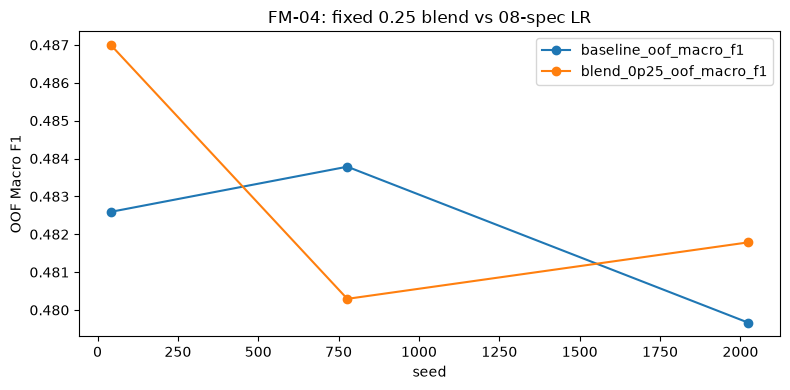

,candidate_id,kind,rank,learning_rate,class_weight,seed,baseline_oof_macro_f1,fm_oof_macro_f1,blend_0p25_oof_macro_f1,blend_0p50_oof_macro_f1,...,paired_delta_0p25_fold_min,early_stopping_epoch_mean,loss_finite,runtime_seconds,feature_count_mean,leakage_check,nan_as_mutation_count,experiment_id,blend_weight_fm,blend_weight_lr
0,FM-04_fixed_rank8_lr3e-4_balanced,fm,8,0.0003,balanced,42,0.482593,0.351593,0.486993,0.454991,...,0.000201,5.0,True,313.308297,14496.0,True,0,FM-04,0.25,0.75
1,FM-04_fixed_rank8_lr3e-4_balanced,fm,8,0.0003,balanced,777,0.483784,0.351075,0.480294,0.446089,...,-0.016759,5.4,True,340.660920,14493.8,True,0,FM-04,0.25,0.75
2,FM-04_fixed_rank8_lr3e-4_balanced,fm,8,0.0003,balanced,2024,0.479667,0.348530,0.481786,0.457266,...,-0.005119,5.2,True,349.246075,14495.2,True,0,FM-04,0.25,0.75


,experiment_id,seed_count,lr08_macro_f1_mean,blend_0p25_macro_f1_mean,blend_0p25_macro_f1_std,delta_vs_lr08_mean,all_seed_delta_positive,feature_count_mean,runtime_seconds_mean,loss_finite,leakage_check,nan_as_mutation_count
0,FM-04,3,0.482014,0.483024,0.003517,0.00101,False,14495.0,334.405097,True,True,0


In [3]:
paths = [RESULT_DIR / f'{RUN_ID}_seed{seed}_oof.csv' for seed in SEEDS]
missing = [str(path) for path in paths if not path.exists()]
if missing:
    raise FileNotFoundError('누락 결과:\n' + '\n'.join(missing))
per_seed = pd.concat([pd.read_csv(path) for path in paths], ignore_index=True).sort_values('seed')
assert per_seed.loss_finite.all() and per_seed.leakage_check.all() and per_seed.nan_as_mutation_count.eq(0).all()
summary = pd.DataFrame([{
    'experiment_id': 'FM-04',
    'seed_count': len(SEEDS),
    'lr08_macro_f1_mean': per_seed.baseline_oof_macro_f1.mean(),
    'blend_0p25_macro_f1_mean': per_seed.blend_0p25_oof_macro_f1.mean(),
    'blend_0p25_macro_f1_std': per_seed.blend_0p25_oof_macro_f1.std(),
    'delta_vs_lr08_mean': per_seed.paired_delta_0p25_oof.mean(),
    'all_seed_delta_positive': bool(per_seed.paired_delta_0p25_oof.gt(0).all()),
    'feature_count_mean': per_seed.feature_count_mean.mean(),
    'runtime_seconds_mean': per_seed.runtime_seconds.mean(),
    'loss_finite': bool(per_seed.loss_finite.all()),
    'leakage_check': bool(per_seed.leakage_check.all()),
    'nan_as_mutation_count': int(per_seed.nan_as_mutation_count.sum()),
}])
per_seed.to_csv(RESULT_DIR / 'FM-04_3seed_per_seed.csv', index=False)
summary.to_csv(RESULT_DIR / 'FM-04_3seed_summary.csv', index=False)
ax = per_seed.plot(x='seed', y=['baseline_oof_macro_f1', 'blend_0p25_oof_macro_f1'], marker='o', figsize=(8, 4), title='FM-04: fixed 0.25 blend vs 08-spec LR')
ax.set_ylabel('OOF Macro F1'); plt.tight_layout()
plt.savefig(RESULT_DIR / 'FM-04_3seed_oof_macro_f1.png', dpi=160)
plt.show()
display(per_seed)
display(summary)
